# Benchmark Dashboard

Interactive exploration of per-category benchmark results for discopt.

This notebook loads JSON results produced by `run_category_benchmarks.py`
and visualizes solver performance across LP, QP, MILP, MIQP, MINLP, and
global optimization categories.

The benchmarking methodology follows the Dolan-Moré performance profile
framework {cite:p}`DolanMore2002` with shifted geometric mean timing
as recommended by {cite:t}`Mittelmann2023`.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_ENABLE_X64", "1")

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

## Load Results

Load the most recent JSON results from the `results/` directory.
Each JSON file contains a `BenchmarkResults` serialization with
per-solver, per-instance solve data.

In [2]:
# Find results directory
results_dir = Path("../../results")
if not results_dir.exists():
    results_dir = Path("results")

# Load all category JSON files
categories = ["lp", "qp", "milp", "miqp", "minlp", "global_opt"]
all_data = {}

for cat in categories:
    # Find most recent file for this category
    pattern = f"{cat}_*_*.json"
    files = sorted(results_dir.glob(pattern), reverse=True)
    if files:
        with open(files[0]) as f:
            all_data[cat] = json.load(f)
        print(f"Loaded {cat}: {files[0].name}")
    else:
        print(f"No results found for {cat}")

print(f"\nLoaded {len(all_data)} categories")

Loaded lp: lp_smoke_2026-02-19T09-28-25.712557.json
Loaded qp: qp_smoke_2026-02-19T09-18-58.516978.json
Loaded milp: milp_smoke_2026-02-19T09-20-43.872368.json
Loaded miqp: miqp_full_2026-02-20T12-53-25.042834.json
Loaded minlp: minlp_smoke_2026-02-19T09-20-51.045831.json
No results found for global_opt

Loaded 5 categories


## Build DataFrames

Convert JSON results into pandas DataFrames for analysis.

In [3]:
# Build a flat DataFrame of all results
rows = []
for cat, data in all_data.items():
    for solver, results in data.get("solver_results", {}).items():
        for r in results:
            rows.append(
                {
                    "category": cat,
                    "instance": r["instance"],
                    "solver": solver,
                    "status": r["status"],
                    "objective": r.get("objective"),
                    "wall_time": r.get("wall_time", float("inf")),
                    "node_count": r.get("node_count", 0),
                    "iterations": r.get("iterations", 0),
                    "bound": r.get("bound"),
                }
            )

df = pd.DataFrame(rows)
df["solved"] = df["status"] == "optimal"
print(f"Total results: {len(df)}")
print(f"Solvers: {df['solver'].unique().tolist()}")
print(f"Categories: {df['category'].unique().tolist()}")
df.head()

Total results: 107
Solvers: ['discopt_ipm', 'discopt_ripopt', 'discopt_ipopt', 'highs']
Categories: ['lp', 'qp', 'milp', 'miqp', 'minlp']


,category,instance,solver,status,objective,wall_time,node_count,iterations,bound,solved
0,lp,lp_2var,discopt_ipm,optimal,-4.0,0.338235,0,0,-4.0,True
1,lp,lp_transport_2x2,discopt_ipm,optimal,70.0,0.125551,0,0,70.0,True
2,lp,lp_diet_3,discopt_ipm,optimal,6.0,0.120819,0,0,6.0,True
3,lp,lp_infeasible,discopt_ipm,unknown,NaN,0.110926,0,0,NaN,False
4,lp,lp_unbounded,discopt_ipm,optimal,0.0,0.112188,0,0,0.0,True


In [4]:
# Summary statistics per solver per category
summary = (
    df.groupby(["category", "solver"])
    .agg(
        total=("instance", "count"),
        solved=("solved", "sum"),
        mean_time=("wall_time", lambda x: x[x < 1e6].mean()),
        median_time=("wall_time", lambda x: x[x < 1e6].median()),
        mean_iters=("iterations", lambda x: x[x > 0].mean()),
    )
    .reset_index()
)
summary["solve_rate"] = summary["solved"] / summary["total"]
summary

,category,solver,total,solved,mean_time,median_time,mean_iters,solve_rate
0,lp,discopt_ipm,5,4,0.161544,0.120819,NaN,0.80
1,lp,discopt_ipopt,5,4,0.000398,0.000383,NaN,0.80
2,lp,discopt_ripopt,5,4,0.000597,0.000586,NaN,0.80
3,lp,highs,5,3,0.000306,0.000296,2.5,0.60
4,milp,discopt_ipm,5,5,0.272203,0.311191,NaN,1.00
5,milp,discopt_ipopt,5,5,0.001006,0.001103,NaN,1.00
6,milp,discopt_ripopt,5,5,0.001279,0.001433,NaN,1.00
7,minlp,discopt_ipm,4,4,1.730718,2.029684,NaN,1.00
8,minlp,discopt_ipopt,4,4,0.467879,0.419679,NaN,1.00
9,minlp,discopt_ripopt,4,3,105.735942,0.785757,NaN,0.75


## Performance Profiles

Dolan-Moré performance profiles {cite:p}`DolanMore2002` show the fraction
of problems solved within a factor $\\tau$ of the best solver's time.

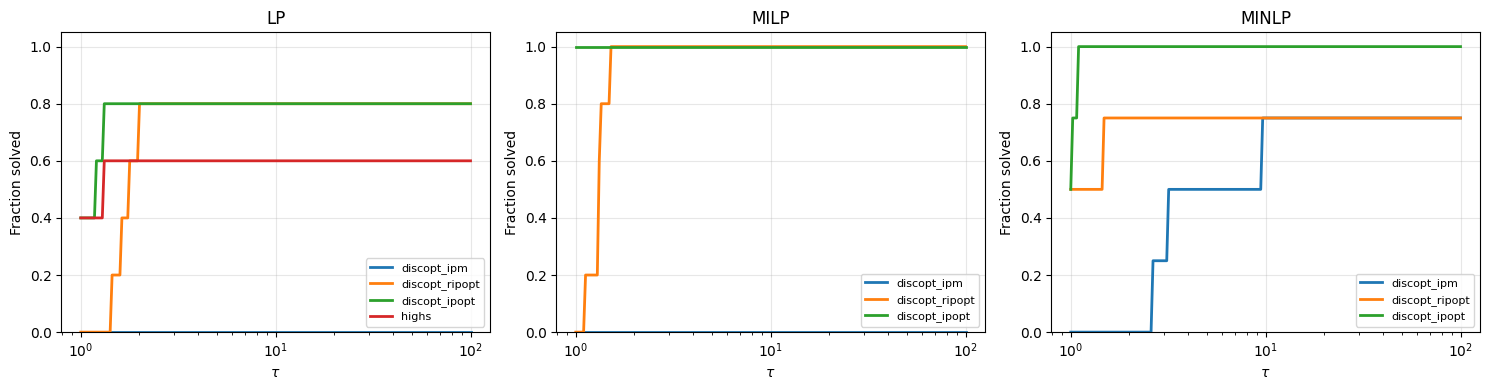

In [5]:
def performance_profile(df_cat, tau_max=100, steps=200):
    """Compute Dolan-Moré performance profile from DataFrame."""
    solvers = df_cat["solver"].unique()
    instances = df_cat["instance"].unique()

    # Build time dict: solver -> {instance: time}
    times = {}
    for s in solvers:
        mask = (df_cat["solver"] == s) & df_cat["solved"]
        times[s] = dict(
            zip(
                df_cat.loc[mask, "instance"],
                df_cat.loc[mask, "wall_time"],
            )
        )

    # Best time per instance
    best = {}
    for inst in instances:
        inst_times = [times[s][inst] for s in solvers if inst in times[s]]
        if inst_times:
            best[inst] = max(min(inst_times), 1e-6)

    tau_vals = np.logspace(0, np.log10(tau_max), steps)
    profiles = {}
    n = len(instances)

    for s in solvers:
        fracs = []
        for tau in tau_vals:
            count = sum(
                1
                for inst in instances
                if inst in times[s] and inst in best and times[s][inst] / best[inst] <= tau
            )
            fracs.append(count / max(n, 1))
        profiles[s] = (tau_vals, np.array(fracs))

    return profiles


# Plot performance profiles for each category
n_cats = len(all_data)
if n_cats > 0:
    fig, axes = plt.subplots(
        1,
        min(n_cats, 3),
        figsize=(5 * min(n_cats, 3), 4),
        squeeze=False,
    )
    for idx, cat in enumerate(sorted(all_data.keys())[:3]):
        ax = axes[0, idx]
        df_cat = df[df["category"] == cat]
        if len(df_cat) == 0:
            continue
        profiles = performance_profile(df_cat)
        for s, (tau, frac) in profiles.items():
            ax.semilogx(tau, frac, label=s, linewidth=2)
        ax.set_xlabel(r"$\tau$")
        ax.set_ylabel("Fraction solved")
        ax.set_title(f"{cat.upper()}")
        ax.legend(fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot")

## Wall-Time Scatter Plots

Pairwise solver comparison: each point is an instance,
axes are log-scale solve times. Points below the diagonal
indicate the x-axis solver is faster.

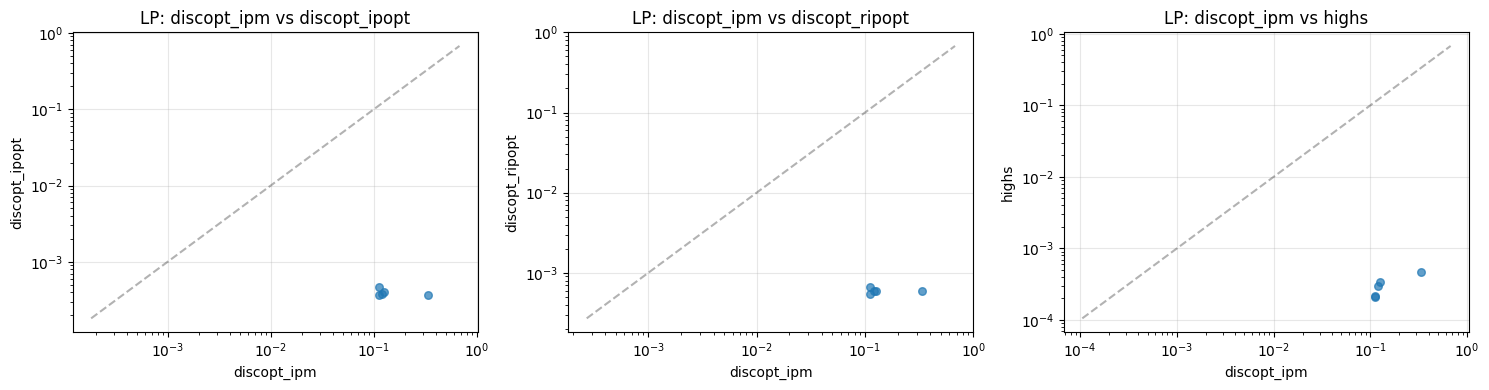

In [6]:
# Pairwise scatter for first available category
if len(all_data) > 0:
    cat = sorted(all_data.keys())[0]
    df_cat = df[df["category"] == cat]
    solvers = sorted(df_cat["solver"].unique())

    n_pairs = len(solvers) * (len(solvers) - 1) // 2
    if n_pairs > 0:
        fig, axes = plt.subplots(
            1,
            min(n_pairs, 3),
            figsize=(5 * min(n_pairs, 3), 4),
            squeeze=False,
        )
        pair_idx = 0
        for i, sa in enumerate(solvers):
            for sb in solvers[i + 1 :]:
                if pair_idx >= 3:
                    break
                ax = axes[0, pair_idx]

                ta = df_cat[df_cat["solver"] == sa].set_index("instance")["wall_time"]
                tb = df_cat[df_cat["solver"] == sb].set_index("instance")["wall_time"]
                common = ta.index.intersection(tb.index)

                if len(common) > 0:
                    x = ta.loc[common].values
                    y = tb.loc[common].values
                    mask = (x < 1e6) & (y < 1e6) & (x > 0) & (y > 0)
                    if mask.any():
                        ax.scatter(x[mask], y[mask], alpha=0.7, s=30)
                        lims = [
                            min(x[mask].min(), y[mask].min()) * 0.5,
                            max(x[mask].max(), y[mask].max()) * 2,
                        ]
                        ax.plot(lims, lims, "k--", alpha=0.3, label="y=x")
                        ax.set_xscale("log")
                        ax.set_yscale("log")

                ax.set_xlabel(sa)
                ax.set_ylabel(sb)
                ax.set_title(f"{cat.upper()}: {sa} vs {sb}")
                ax.grid(True, alpha=0.3)
                pair_idx += 1
        plt.tight_layout()
        plt.show()

## Iteration Count Comparison

Bar chart comparing median iteration counts across solvers.

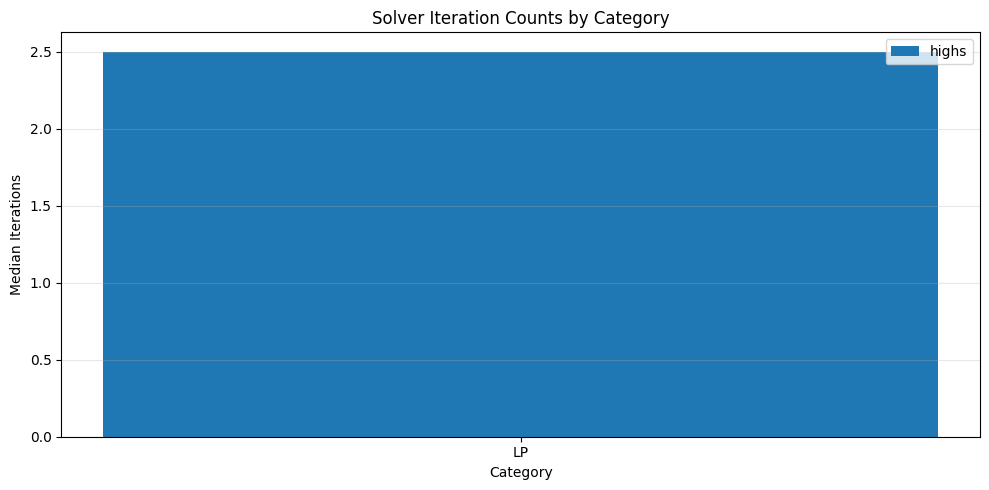

In [7]:
# Iteration comparison
iter_data = (
    df[df["iterations"] > 0].groupby(["category", "solver"])["iterations"].median().reset_index()
)

if len(iter_data) > 0:
    cats = iter_data["category"].unique()
    fig, ax = plt.subplots(figsize=(10, 5))

    solvers = sorted(iter_data["solver"].unique())
    x = np.arange(len(cats))
    width = 0.8 / max(len(solvers), 1)

    for i, s in enumerate(solvers):
        vals = []
        for c in cats:
            mask = (iter_data["category"] == c) & (iter_data["solver"] == s)
            v = iter_data.loc[mask, "iterations"].values
            vals.append(v[0] if len(v) > 0 else 0)
        ax.bar(x + i * width, vals, width, label=s)

    ax.set_xlabel("Category")
    ax.set_ylabel("Median Iterations")
    ax.set_title("Solver Iteration Counts by Category")
    ax.set_xticks(x + width * (len(solvers) - 1) / 2)
    ax.set_xticklabels([c.upper() for c in cats])
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("No iteration data available")

## Gap Closure Analysis (Global Optimization)

For global optimization instances, analyze the quality of bounds
and the optimality gap at termination.

In [8]:
# Gap analysis for global_opt category
df_global = df[df["category"] == "global_opt"].copy()

if len(df_global) > 0:
    # Compute relative gap
    def rel_gap(row):
        obj = row["objective"]
        bnd = row["bound"]
        if obj is None or bnd is None:
            return None
        if abs(obj) < 1e-10:
            return abs(obj - bnd)
        return abs(obj - bnd) / max(abs(obj), 1e-10)

    df_global["gap"] = df_global.apply(rel_gap, axis=1)

    gap_summary = (
        df_global[df_global["gap"].notna()]
        .groupby("solver")["gap"]
        .agg(["mean", "median", "max", "count"])
    )
    print("Gap statistics by solver:")
    print(gap_summary.to_string())

    # Bar chart of proved optimal count
    proved = df_global[df_global["status"] == "optimal"].groupby("solver").size()
    total = df_global.groupby("solver").size()

    fig, ax = plt.subplots(figsize=(8, 4))
    proved.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_ylabel("Proved Optimal")
    ax.set_title("Global Optimization: Proved Optimal Count")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("No global_opt data available")

No global_opt data available


## Historical Trends

If JSONL history files are available, plot solved counts over time.

Found 2 history files
  global_opt_history.jsonl
  smoke_history.jsonl


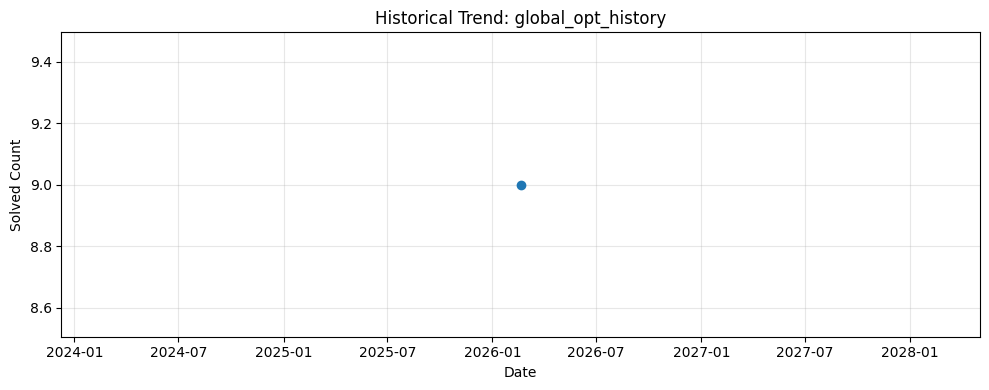

In [9]:
# Load history if available
history_dir = Path("../../reports/history")
if not history_dir.exists():
    history_dir = Path("reports/history")

if history_dir.exists():
    history_files = sorted(history_dir.glob("*.jsonl"))
    if history_files:
        print(f"Found {len(history_files)} history files")
        for hf in history_files[:5]:
            print(f"  {hf.name}")

        # Parse first history file as example
        records = []
        with open(history_files[0]) as f:
            for line in f:
                records.append(json.loads(line))

        if records:
            df_hist = pd.DataFrame(records)
            if "timestamp" in df_hist.columns and "solved_count" in df_hist.columns:
                df_hist["timestamp"] = pd.to_datetime(df_hist["timestamp"])
                fig, ax = plt.subplots(figsize=(10, 4))
                ax.plot(
                    df_hist["timestamp"],
                    df_hist["solved_count"],
                    "o-",
                    linewidth=2,
                )
                ax.set_xlabel("Date")
                ax.set_ylabel("Solved Count")
                ax.set_title(f"Historical Trend: {history_files[0].stem}")
                ax.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
    else:
        print("No history files found")
else:
    print("No history directory found. Run benchmarks first.")

## References

```{bibliography}
:filter: docname in docnames
```